In [1]:
from jax import jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import config
import jax
import sys
from functools import partial

sys.path.append("../src")

jax.config.update("jax_platform_name", "cpu")

config.update("jax_enable_x64", True)

In [2]:
from configuration.rte2d_settings_ex7_oerfm2 import get_config
from constraints.continuous2d_oe_2 import (
    OddEvenDecompositionPointwiseBoundaryConstraint2D as BC,
    OddEvenDecompositionPointwiseInteriorConstraint2D as EQ,
)
from geometry.meshxd_ds import UniformMeshXYV
from modules.generator_2_copy import SampleC
from modules.solution_2_copy import OddEvenDecompositionConstructor2D
from solver.least_square import solve
from utils.integrate import leggauss

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["j/r"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_j = UniformMeshXYV(domain=domain, strides=strides)
mesh_r = UniformMeshXYV(domain=domain, strides=strides)

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_y, dummy_theta = jnp.split(
    jnp.array([0.1, 0.5, 0.2]), 3, axis=0)
params = {}
# eq_instance = rte.apply(params, dummy_x, dummy_y, dummy_theta)
# bc_instance = bc.apply(params, dummy_x, dummy_y, dummy_theta)

In [6]:
# eq_instance.shape, bc_instance.shape

In [7]:
def eq_fn(x, y, theta):
    return partial(rte.apply, params)(x, y, theta)


def bc_fn(x, y, theta):
    return partial(bc.apply, params)(x, y, theta)


def rhs_fn(x, y, theta):
    quadratures = leggauss(num_quads, (0, jnp.pi / 2))
    pts, ws = quadratures

    def q_sym1(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            + source_fn(x, y, theta + jnp.pi)
            + source_fn(x, y, -theta)
            + source_fn(x, y, -theta + jnp.pi)
        )

    def q_sym2(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            + source_fn(x, y, theta + jnp.pi)
            - source_fn(x, y, -theta)
            - source_fn(x, y, -theta + jnp.pi)
        )

    def q_asym1(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            - source_fn(x, y, theta + jnp.pi)
            + source_fn(x, y, -theta)
            - source_fn(x, y, -theta + jnp.pi)
        )

    def q_asym2(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            - source_fn(x, y, theta + jnp.pi)
            - source_fn(x, y, -theta)
            + source_fn(x, y, -theta + jnp.pi)
        )

    weighted_sum1 = vmap(q_sym1, [None, None, 0])(x, y, pts) * ws
    avg_q1 = jnp.sum(weighted_sum1) / jnp.pi * 2

    rhs = jnp.stack(
        [
            avg_q1.squeeze(),
            kn**2 * (q_sym1(x, y, theta) - avg_q1).squeeze(),
            kn * q_asym1(x, y, theta).squeeze(),
            kn**2 * q_sym2(x, y, theta).squeeze(),
            kn * q_asym2(x, y, theta).squeeze(),
        ],
        axis=0,
    )
    return rhs


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

In [8]:
sampler = SampleC(
    domain=domain, collocation_sizes=collocation_sizes, mode=mode)
pts_int, pts_left, pts_right, pts_lower, pts_upper = (
    sampler.pts_int,
    sampler.pts_left,
    sampler.pts_right,
    sampler.pts_lower,
    sampler.pts_upper,
)

In [9]:
# Evaluate the functions
bc_left, bc_right, bc_lower, bc_upper = (
    vmap_bc_fn(*pts_left),
    vmap_bc_fn(*pts_right),
    vmap_bc_fn(*pts_lower),
    vmap_bc_fn(*pts_upper),
)
print(
    f"bc_left.shape: {bc_left.shape}, bc_right.shape: {bc_right.shape}, bc_lower.shape: {bc_lower.shape}, bc_upper.shape: {bc_upper.shape}"
)

bc_left.shape: (1024, 2, 1024), bc_right.shape: (1024, 2, 1024), bc_lower.shape: (1024, 2, 1024), bc_upper.shape: (1024, 2, 1024)


In [10]:
eq_int = vmap_eq_fn(*pts_int)
print(f"eq_int.shape: {eq_int.shape}")  # ((Nx-2) * (Ny-2) * (Ntheta-2),3,32)

eq_int.shape: (24576, 5, 1024)


In [11]:
x_int, y_int, theta_int = pts_int
pts_int = x_int.squeeze(), y_int.squeeze(), theta_int.squeeze()
rhs_int = vmap_rhs_fn(*pts_int)
print(f"rhs_int.shape: {rhs_int.shape}")

rhs_int.shape: (24576, 5)


In [12]:
def ex_solution_2d(x: jnp.ndarray, y: jnp.ndarray, theta: jnp.ndarray) -> jnp.ndarray:
    return jnp.exp(-x) * jnp.exp(-y)


vmap_ex_fn = vmap(jit(ex_solution_2d))

In [13]:
# Save the data
matrix_A = np.concatenate(
    [
        bc_left.reshape(-1, num_unknowns * 2),
        bc_right.reshape(-1, num_unknowns * 2),
        bc_lower.reshape(-1, num_unknowns * 2),
        bc_upper.reshape(-1, num_unknowns * 2),
        eq_int.reshape(-1, num_unknowns * 2),
    ],
    axis=0,
)

vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size_x, bdy_size_y, bdy_size_theta = collocation_sizes["boundary"]
vector_b[: 2 * bdy_size_y * bdy_size_theta: 2,
         0] = 2 * vmap_ex_fn(*pts_left).squeeze()
vector_b[
    2 * bdy_size_y * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_right).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_lower).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta + 2 * bdy_size_x * bdy_size_theta: 4
    * bdy_size_y
    * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_upper).squeeze()

vector_b[4 * bdy_size_y * bdy_size_theta + 4 * bdy_size_x * bdy_size_theta:, 0] = (
    rhs_int.reshape(-1)
)


print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (131072, 1024), Vector b: (131072, 1)


In [14]:
print("Matrix A 内存 %.2f MB" % (matrix_A.nbytes / 1024**2))
print("Vector b 内存 %.2f MB" % (vector_b.nbytes / 1024**2))

num_zero = np.sum(matrix_A == 0).item()
total = matrix_A.size
sparsity = num_zero / total
print(f"A的稀疏度 = {sparsity:.2%} (零元素比例)")
num_zero = np.sum(vector_b == 0).item()
total = vector_b.size
sparsity = num_zero / total
print(f"b的稀疏度 = {sparsity:.2%} (零元素比例)")

Matrix A 内存 1024.00 MB
Vector b 内存 1.00 MB
A的稀疏度 = 10.16% (零元素比例)
b的稀疏度 = 3.13% (零元素比例)


In [15]:
vector_U = solve(matrix_A, vector_b, c=regularizer)
print(f"Vector U: {vector_U.shape}")

Vector U: (1024, 1)


In [16]:
error = matrix_A @ vector_U - vector_b
(
    np.abs(error).max(),
    np.abs(error).mean(),
)

(138.99337907946122, 0.2216415852732522)

In [17]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns * 2,
)
constructor = OddEvenDecompositionConstructor2D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [18]:
def approx_fn(x, y, theta):
    return partial(constructor.apply, params)(x, y, theta)

In [19]:
def rho(x, y):
    return jnp.exp(-x) * jnp.exp(-y)

In [20]:
def aver_fn(x, y):
    quadratures = leggauss(num_quads, (-jnp.pi, jnp.pi))
    pts, ws = quadratures
    weighted_sum = vmap(approx_fn, [None, None, 0])(x, y, pts) @ ws
    return weighted_sum / jnp.pi / 2.0

In [21]:
# vmap_approx_fn = vmap(approx_fn)
approx_fn = jit(approx_fn)

In [22]:
dummy_z = jnp.array([0, 0, 0])
dummy_x, dummy_y, dummy_v = jnp.split(dummy_z, 3, axis=-1)
print(f"f({dummy_z}) = {approx_fn(dummy_x, dummy_y, dummy_v)}")

f([0 0 0]) = 1.0264816740034977


In [23]:
def mask_C(X, Y):
    in_top = (Y >= 2.0) & (Y <= 3.0) & (X >= -3.0) & (X <= 3.0)
    in_bot = (Y >= -3.0) & (Y <= -2.0) & (X >= -3.0) & (X <= 3.0)
    in_left = (X >= -3.0) & (X <= -2.0) & (Y >= -2.0) & (Y <= 2.0)
    return in_top | in_bot | in_left


def mask_C_curve(X, Y):
    """
    C-shaped domain mask:
    - Left half-circle (半圆环)
    - Top and bottom horizontal rectangles
    """
    # -----------------------------
    # Left half-circle
    # -----------------------------
    R_outer = 3.0
    R_inner = 2.0
    radius = np.sqrt((X - 1) ** 2 + Y**2)
    left_circle = (X <= 1) & (radius <= R_outer) & (radius >= R_inner)

    # -----------------------------
    # Top and bottom rectangles
    # -----------------------------
    top_rect = (Y >= 2.0) & (Y <= 3.0) & (X >= 1.0) & (X <= 2.0)
    bottom_rect = (Y >= -3.0) & (Y <= -2.0) & (X >= 1.0) & (X <= 2.0)

    # -----------------------------
    # Combine
    # -----------------------------
    return left_circle | top_rect | bottom_rect

In [24]:
mesh_x = np.linspace(-2.0, 2.0, 257)
mesh_y = np.linspace(-3.0, 3.0, 257)

X, Y = np.meshgrid(mesh_x, mesh_y)

rho_approx = vmap(aver_fn, [0, 0])(
    X.reshape(-1, 1),
    Y.reshape(-1, 1),
).reshape(X.shape)

rho_ex = vmap(rho, [0, 0])(X, Y)
shape_matrix = mask_C_curve(X, Y)
shape_matrix = shape_matrix.astype(float)
shape_matrix[~mask_C_curve(X, Y)] = None

F = rho_ex * shape_matrix
F_hat = rho_approx * shape_matrix
F.shape, F_hat.shape, kn

((257, 257), (257, 257), 1.0)

In [25]:
# np.savez(
#     f"../src/data/OERFM2d_ex6_solutions_{kn:.1e}.npz",
#     X=X,
#     Y=Y,
#     rho_hat=rho_approx * shape_matrix,
#     rho_ex=rho_ex * shape_matrix,
# )

# print(kn)

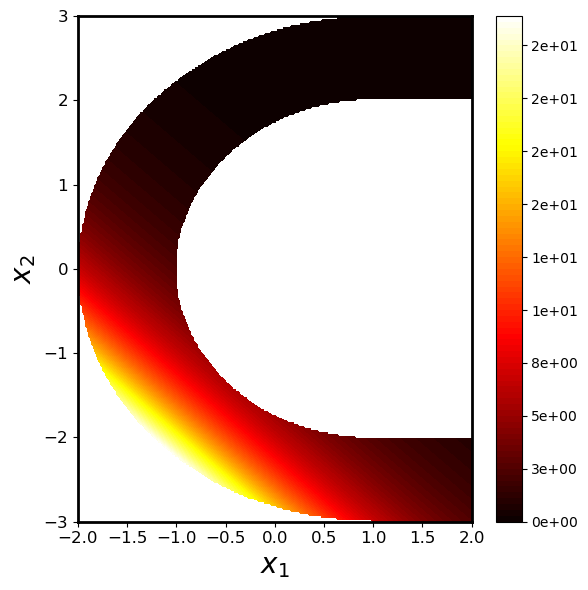

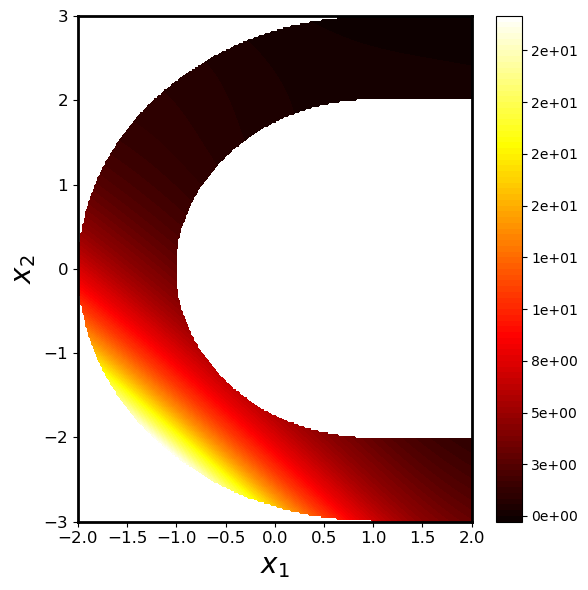

In [26]:
# ==================== 图1：Reference solution ====================
plt.figure(figsize=(6, 6))
ax1 = plt.gca()
contour1 = plt.contourf(X, Y, F, 100, cmap="hot")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$",  fontsize=20)
plt.ylabel(r"$x_2$",  fontsize=20)
plt.colorbar(contour1, format="%.0e")
# plt.title("Reference solution")

# 设置边框线宽
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

plt.tight_layout()
# plt.savefig("./figures/reference_solution.png", dpi=300, bbox_inches="tight")
# plt.show()
# plt.close()

# ==================== 图2：OERFM solution ====================
plt.figure(figsize=(6, 6))
ax2 = plt.gca()
contour2 = plt.contourf(X, Y, F_hat, 100, cmap="hot")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", fontsize=20)
plt.ylabel(r"$x_2$", fontsize=20)
plt.colorbar(contour2, format="%.0e")
# plt.title("OERFM solution")

# 设置边框线宽
ax2.spines["bottom"].set_linewidth(2)
ax2.spines["left"].set_linewidth(2)
ax2.spines["right"].set_linewidth(2)
ax2.spines["top"].set_linewidth(2)

plt.tight_layout()
# plt.savefig("./figures/oerfm_solution.png", dpi=300, bbox_inches="tight")
# plt.show()
# plt.close()

# ==================== 图3：Error ====================
# plt.figure(figsize=(6,6))
# ax3 = plt.gca()
# contour3 = plt.contourf(X, Y, np.abs(F - F_hat), 100, cmap="hot_r")
# plt.xticks(size=12)
# plt.yticks(size=12)
# plt.xlabel(r"$x_1$")
# plt.ylabel(r"$x_2$")
# plt.colorbar(contour3, format="%.0e")
# plt.title("Error")

# # 设置边框线宽
# ax3.spines["bottom"].set_linewidth(2)
# ax3.spines["left"].set_linewidth(2)
# ax3.spines["right"].set_linewidth(2)
# ax3.spines["top"].set_linewidth(2)

# plt.tight_layout()
# plt.savefig("./figures/error.png", dpi=300, bbox_inches='tight')
# plt.show()
# plt.close()

In [27]:
mask = ~np.isnan(F)
err = np.linalg.norm((F_hat - F)[mask]) / np.linalg.norm(F[mask])
err

0.05587490646224524

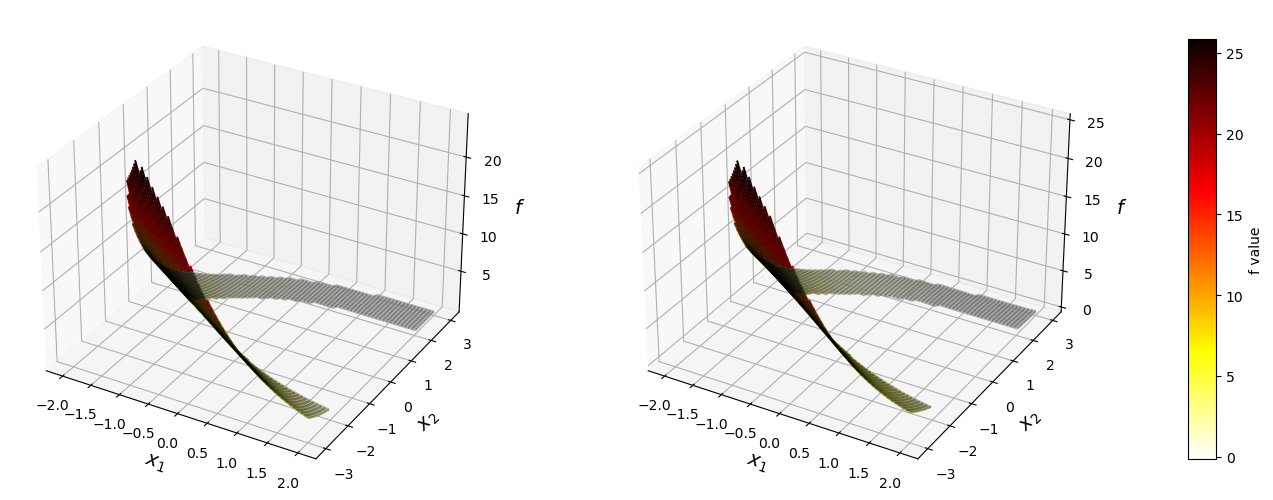

In [28]:
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np
from jax import vmap
import jax.numpy as jnp
from mpl_toolkits.mplot3d import Axes3D


# -----------------------------
# 画图
# -----------------------------
fig = plt.figure(figsize=(14, 6))

vmin = min(np.nanmin(F), np.nanmin(F_hat))
vmax = max(np.nanmax(F), np.nanmax(F_hat))
norm = plt.Normalize(vmin, vmax)

stride = 4

# -----------------------------
# 左图 exact
# -----------------------------
ax1 = fig.add_axes([0.05, 0.1, 0.4, 0.8], projection="3d")

ax1.plot_wireframe(
    X[::stride, ::stride],
    Y[::stride, ::stride],
    F[::stride, ::stride],
    rstride=1,
    cstride=1,
    color="black",
    alpha=0.3,
)

for i in range(0, F.shape[0], stride):
    for j in range(0, F.shape[1], stride):

        if not np.isnan(F[i, j]):

            color = cm.hot_r(norm(F[i, j]))

            i2 = min(i + stride, F.shape[0] - 1)
            j2 = min(j + stride, F.shape[1] - 1)

            if not np.isnan(F[i2, j]):
                ax1.plot(
                    [X[i, j], X[i2, j]],
                    [Y[i, j], Y[i2, j]],
                    [F[i, j], F[i2, j]],
                    color=color,
                    linewidth=1,
                )

            if not np.isnan(F[i, j2]):
                ax1.plot(
                    [X[i, j], X[i, j2]],
                    [Y[i, j], Y[i, j2]],
                    [F[i, j], F[i, j2]],
                    color=color,
                    linewidth=1,
                )

ax1.set_xlabel(r"$x_1$", fontsize=14)
ax1.set_ylabel(r"$x_2$", fontsize=14)
ax1.set_zlabel(r"$f$", fontsize=14)


# -----------------------------
# 右图 approx
# -----------------------------
ax2 = fig.add_axes([0.48, 0.1, 0.4, 0.8], projection="3d")

ax2.plot_wireframe(
    X[::stride, ::stride],
    Y[::stride, ::stride],
    F_hat[::stride, ::stride],
    rstride=1,
    cstride=1,
    color="black",
    alpha=0.3,
)

for i in range(0, F_hat.shape[0], stride):
    for j in range(0, F_hat.shape[1], stride):

        if not np.isnan(F_hat[i, j]):

            color = cm.hot_r(norm(F_hat[i, j]))

            i2 = min(i + stride, F_hat.shape[0] - 1)
            j2 = min(j + stride, F_hat.shape[1] - 1)

            if not np.isnan(F_hat[i2, j]):
                ax2.plot(
                    [X[i, j], X[i2, j]],
                    [Y[i, j], Y[i2, j]],
                    [F_hat[i, j], F_hat[i2, j]],
                    color=color,
                    linewidth=1,
                )

            if not np.isnan(F_hat[i, j2]):
                ax2.plot(
                    [X[i, j], X[i, j2]],
                    [Y[i, j], Y[i, j2]],
                    [F_hat[i, j], F_hat[i, j2]],
                    color=color,
                    linewidth=1,
                )

ax2.set_xlabel(r"$x_1$", fontsize=14)
ax2.set_ylabel(r"$x_2$", fontsize=14)
ax2.set_zlabel(r"$f$", fontsize=14)


# -----------------------------
# colorbar
# -----------------------------
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cm.hot_r, norm=norm)
sm.set_array([])

fig.colorbar(sm, cax=cbar_ax, label="f value")